# Exploratory Data Analysis - NASA C-MAPSS (FD001)

This notebook characterises the raw turbofan sensor data and identifies the
constant / non-informative sensors to drop before modelling.

**Key questions**

1. What is the data schema and scale?
2. Which sensors are constant (no signal) and should be dropped?
3. How do sensors drift over an engine's life cycle?
4. Which sensors are correlated (redundant)?
5. How do operational settings vary (single- vs multi-condition subsets)?


In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Ensure the project root is importable when the notebook runs from notebooks/.
sys.path.insert(0, str(Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from src.config import COLUMN_NAMES, CONSTANT_SENSORS, KEPT_SENSORS, REPORTS_DIR, SENSOR_COLS, SETTING_COLS
from src.data_loader import engine_units, load_raw
from src.features import build_rul_target
from src.seeds import SEED, set_seed

set_seed()
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print("figures will be saved to", REPORTS_DIR)


figures will be saved to E:\Projects\Git Projects\rul-cmapss\reports


## 1. Load the data

In [2]:
train = load_raw("train", fd=1)
test = load_raw("test", fd=1)

print("train shape:", train.shape)
print("test  shape:", test.shape)
print("train engines:", engine_units(train).shape[0])
print("test  engines:", engine_units(test).shape[0])
train.head()


train shape: (20631, 26)
test  shape: (13096, 26)
train engines: 100
test  engines: 100


,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Schema

Each row is one engine at one time step (`cycle`). The first column is the
engine **unit id**, then the time index, then **3 operational settings**, then
**21 sensor channels** (`s1..s21`). Training data is run-to-failure (the last
row of each unit is the failure point); test data is truncated before failure.


In [3]:
schema = pd.DataFrame({
    "column": COLUMN_NAMES,
    "meaning": (
        ["engine unit id", "time cycle (per unit)"]
        + ["operational setting"] * 3
        + [f"sensor {i}" for i in range(1, 22)]
    ),
})
schema


,column,meaning
0,unit,engine unit id
1,cycle,time cycle (per unit)
2,setting_1,operational setting
3,setting_2,operational setting
4,setting_3,operational setting
5,s1,sensor 1
6,s2,sensor 2
7,s3,sensor 3
8,s4,sensor 4
9,s5,sensor 5


## 3. Constant / non-informative sensors

A sensor that never changes cannot carry a degradation signal. We compute the
per-sensor standard deviation across the entire training fleet; sensors with
(essentially) zero variance are dropped.


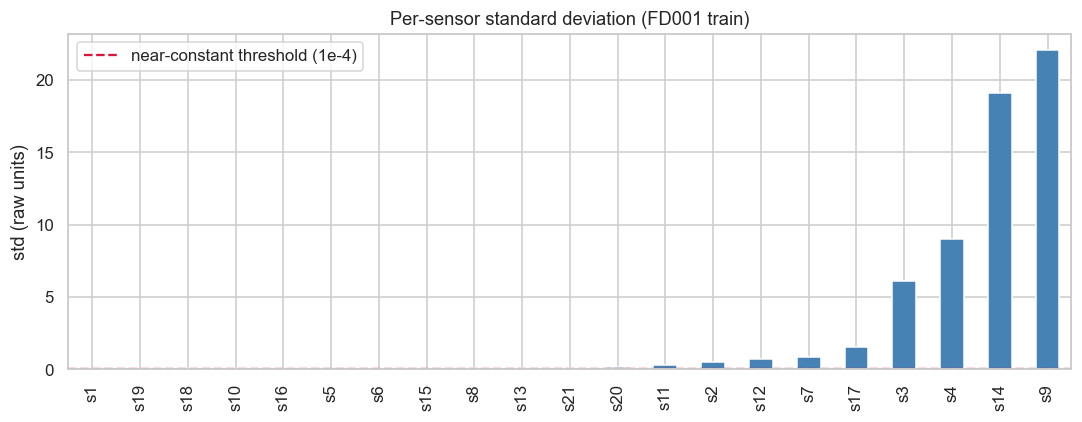

Constant sensors (std < 1e-4): ['s1', 's19', 's18', 's10', 's16', 's5']


In [4]:
sensor_std = train[SENSOR_COLS].std().sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
sensor_std.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("std (raw units)")
ax.set_title("Per-sensor standard deviation (FD001 train)")
ax.axhline(1e-4, color="crimson", ls="--", lw=1.5, label="near-constant threshold (1e-4)")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_sensor_std.png", bbox_inches="tight")
plt.show()

print("Constant sensors (std < 1e-4):", sensor_std[sensor_std < 1e-4].index.tolist())


`s6` has a std slightly above the threshold but is effectively constant -
it takes only two quantised values across the whole fleet. It is dropped as
non-informative too (this matches the standard C-MAPSS drop-list in the
literature: `s1, s5, s6, s10, s16, s18, s19`).


In [5]:
for s in ["s6"]:
    print(s, "-> unique values:", np.sort(train[s].unique()),
          "| range/mean =", (train[s].max() - train[s].min()) / train[s].mean())


s6 -> unique values: [21.6  21.61] | range/mean = 0.0004627529414956757


### Drop list (matches `src.config.CONSTANT_SENSORS`)

In [6]:
print("Dropped:", CONSTANT_SENSORS)
print("Kept   :", KEPT_SENSORS)
print("n kept sensors:", len(KEPT_SENSORS))


Dropped: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Kept   : ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
n kept sensors: 14


## 4. Sensor drift over the engine life cycle

We min-max scale each sensor to a common range and plot how it evolves with
cycle. Informative sensors show a monotonic drift toward end-of-life (the
degradation signal); non-drifting sensors would be redundant with time.


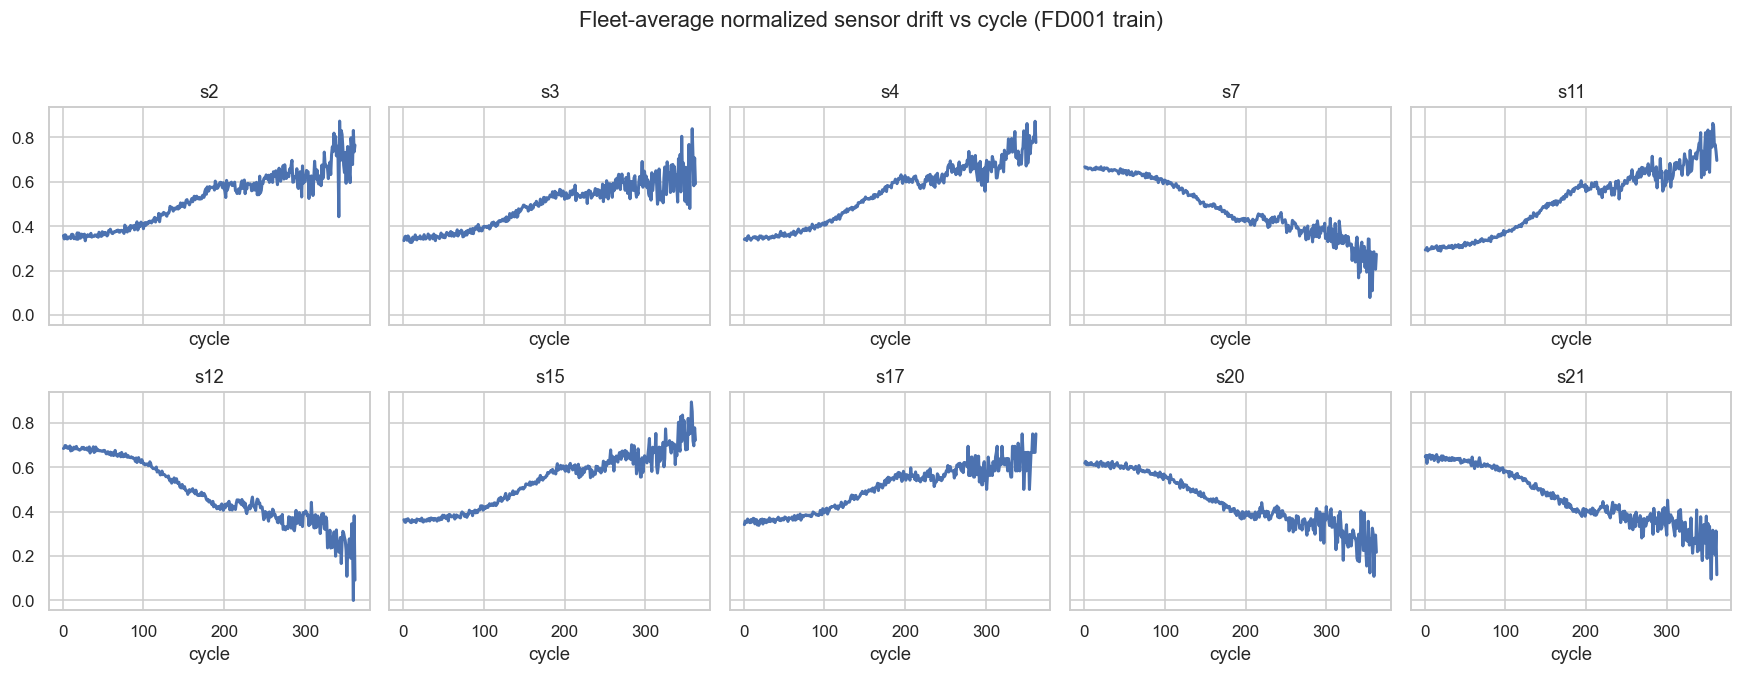

In [7]:
scaled = train.copy()
scaled[SENSOR_COLS] = MinMaxScaler().fit_transform(scaled[SENSOR_COLS])
scaled["rul"] = build_rul_target(train)

probe_sensors = ["s2", "s3", "s4", "s7", "s11", "s12", "s15", "s17", "s20", "s21"]

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True, sharey=True)
for ax, s in zip(axes.ravel(), probe_sensors):
    avg = scaled.groupby("cycle")[s].mean()
    ax.plot(avg.index, avg.values, lw=2)
    ax.set_title(s)
    ax.set_xlabel("cycle")
fig.suptitle("Fleet-average normalized sensor drift vs cycle (FD001 train)", y=1.02)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_sensor_drift_fleet.png", bbox_inches="tight")
plt.show()


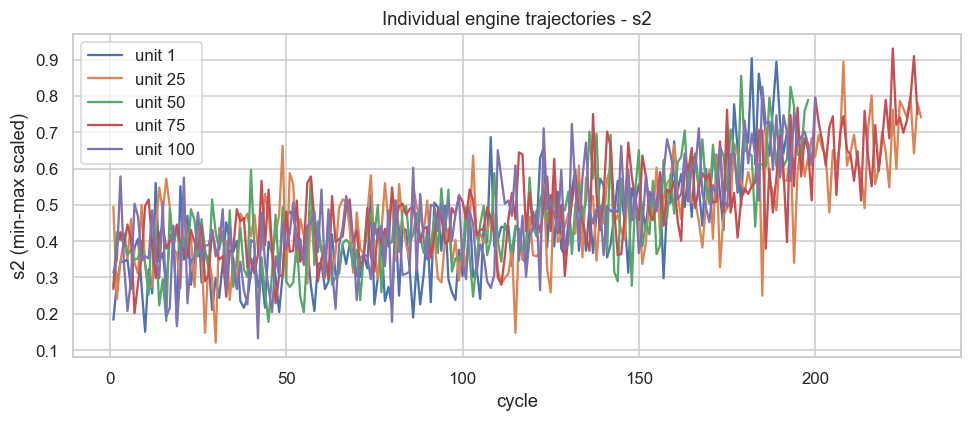

In [8]:
s = "s2"
fig, ax = plt.subplots(figsize=(9, 4))
for u in [1, 25, 50, 75, 100]:
    traj = scaled[scaled["unit"] == u]
    ax.plot(traj["cycle"], traj[s], label=f"unit {u}", lw=1.5)
ax.set_xlabel("cycle")
ax.set_ylabel(f"{s} (min-max scaled)")
ax.set_title(f"Individual engine trajectories - {s}")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_sensor_trajectories.png", bbox_inches="tight")
plt.show()


## 5. Correlation analysis

Strongly correlated sensors are redundant for a linear model and can inflate
multicollinearity. We keep them for the tree/sequence models (which are
robust to redundancy) but note the clusters for feature-selection context.


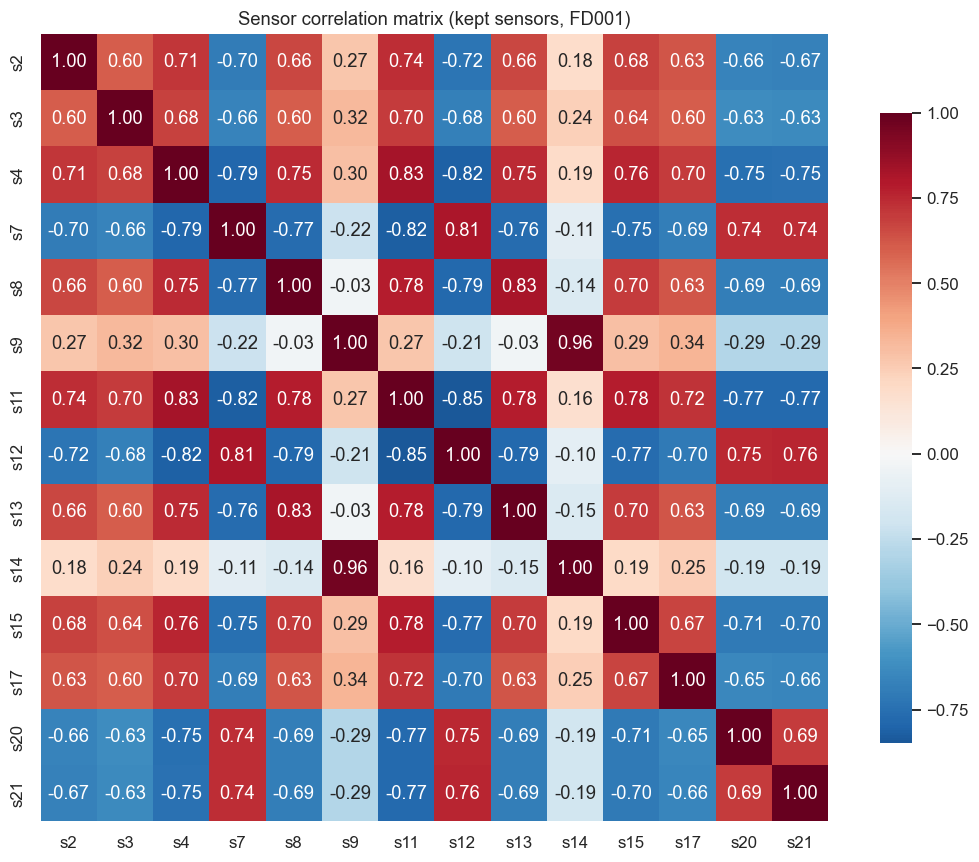

In [9]:
corr = train[KEPT_SENSORS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Sensor correlation matrix (kept sensors, FD001)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_correlation.png", bbox_inches="tight")
plt.show()


## 6. Operational settings

FD001 is a **single operating condition** (the three settings are constant),
so global normalisation is sufficient. FD002/FD004 contain **six operating
regimes**, which is why the pipeline uses per-condition normalisation for those
subsets (`src.features.ConditionNormalizer`).


In [10]:
fd1_settings = load_raw("train", 1)[SETTING_COLS]
fd2_settings = load_raw("train", 2)[SETTING_COLS]

print("FD001 unique setting combinations:", fd1_settings.drop_duplicates().shape[0])
print("FD002 unique setting combinations:", fd2_settings.drop_duplicates().shape[0])

kmeans = KMeans(n_clusters=6, random_state=SEED, n_init=10).fit(fd2_settings)
print("FD002 detected regimes (KMeans k=6):", np.bincount(kmeans.labels_))


FD001 unique setting combinations: 1423
FD002 unique setting combinations: 9824
FD002 detected regimes (KMeans k=6): [13458  8122  8002  8044  8096  8037]


C:\Users\asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
 

## Conclusion

- **Schema**: 26 columns = unit + cycle + 3 settings + 21 sensors.
- **Drop** `s1, s5, s6, s10, s16, s18, s19` (constant / quantised, no signal).
- **Keep** the remaining 14 sensors, which exhibit clear end-of-life drift.
- **Normalisation**: global z-score suffices for FD001; per-condition is
  required for FD002-FD004.

These findings are codified in `src/config.py` and reused by the feature
engineering, training and evaluation modules.
